In [1]:
import mne
import csv
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
from mne import combine_evoked
from mne.minimum_norm import apply_inverse
import random
from mne.datasets import sample
import math
from mne.datasets import fetch_fsaverage
import os.path as op
import seaborn as sns
import pandas as pd

In [2]:
fs_dir = fetch_fsaverage(verbose=True)
subjects_dir = op.dirname(fs_dir)
subject = 'fsaverage'
trans = 'fsaverage'  # MNE has a built-in fsaverage transformation
snr = 3.0
lambda2 = 1.0 / snr ** 2
src = mne.setup_source_space(subject, spacing='ico4', add_dist='patch',subjects_dir=subjects_dir)
conductivity = (0.3, 0.006, 0.3)  # for three layers
model = mne.make_bem_model(subject=subject, ico=3,conductivity=conductivity,subjects_dir=subjects_dir)
bem = mne.make_bem_solution(model)

0 files missing from root.txt in C:\Users\dell\mne_data\MNE-fsaverage-data
0 files missing from bem.txt in C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage
Setting up the source space with the following parameters:

SUBJECTS_DIR = C:\Users\dell\mne_data\MNE-fsaverage-data
Subject      = fsaverage
Surface      = white
Icosahedron subdivision grade 4

>>> 1. Creating the source space...

Doing the icosahedral vertex picking...
Loading C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.white...
Mapping lh fsaverage -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 2562/163842 selected to source space (ico = 4)

Loading C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\surf\rh.white...
Mapping rh fsaverage -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\dell\mn

c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\utils\check.py:92: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LooseVersion(library.__version__) < LooseVersion(min_version):
c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\mne\utils\check.py:92: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LooseVersion(library.__version__) < LooseVersion(min_version):


    Computing patch statistics...
    Patch information added...
    Computing patch statistics...
    Patch information added...
You are now one step closer to computing the gain matrix
Creating the BEM geometry...
Going from 5th to 3th subdivision of an icosahedron (n_tri: 20480 -> 1280)
Going from 5th to 3th subdivision of an icosahedron (n_tri: 20480 -> 1280)
Going from 5th to 3th subdivision of an icosahedron (n_tri: 20480 -> 1280)
outer skin  CM is  -0.21 -19.38  -0.22 mm
outer skull CM is  -0.19 -19.35  -0.49 mm
inner skull CM is  -0.53 -21.10   6.21 mm
Checking that surface outer skull is inside surface outer skin  ...
Checking that surface inner skull is inside surface outer skull ...
Checking distance between outer skin  and outer skull surfaces...
Minimum distance between the outer skin  and outer skull surfaces is approximately    1.6 mm
Checking distance between outer skull and inner skull surfaces...
Minimum distance between the outer skull and inner skull surfaces is app

In [3]:
stc_EFE1 = mne.read_source_estimate('./stc_result/reg_SCE_EFE1_beta')
stc_EFE1_p = mne.read_source_estimate('./stc_result/reg_SCE_EFE1_mlog10_p_val')
stc_EX1 = mne.read_source_estimate('./stc_result/reg_SCE_EX1_beta')
stc_EX1_p = mne.read_source_estimate('./stc_result/reg_SCE_EX1_mlog10_p_val')
stc_AI1 = mne.read_source_estimate('./stc_result/reg_SCE_AI1_beta')
stc_AI1_p = mne.read_source_estimate('./stc_result/reg_SCE_AI1_mlog10_p_val')
stc_AL1 = mne.read_source_estimate('./stc_result/reg_SCE_AL1_beta')
stc_AL1_p = mne.read_source_estimate('./stc_result/reg_SCE_AL1_mlog10_p_val')
stc_EFE2 = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_beta')
stc_EFE2_p = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_mlog10_p_val')
stc_AL2 = mne.read_source_estimate('./stc_result/reg_SRE_AL2_beta')
stc_AL2_p = mne.read_source_estimate('./stc_result/reg_SRE_AL2_mlog10_p_val')
stc_EX2 = mne.read_source_estimate('./stc_result/reg_SRE_EX2_beta')
stc_EX2_p = mne.read_source_estimate('./stc_result/reg_SRE_EX2_mlog10_p_val')
stc_REX2 = mne.read_source_estimate('./stc_result/reg_SRR_REX2_beta')
stc_REX2_p = mne.read_source_estimate('./stc_result/reg_SRR_REX2_mlog10_p_val')
stc_RAL2 = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_beta')
stc_RAL2_p = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_mlog10_p_val')
stc_RAI1 = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_beta')
stc_RAI1_p = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_mlog10_p_val')

In [5]:
DATA_AI1 = stc_AI1.data

In [6]:
stc_AI1.data = np.where(DATA_AI1 <= 0, -DATA_AI1, 0)

In [ ]:
vertno_max, time_max = stc_RAL2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_RAL2.plot(**surfer_kwargs)

Using control points [1.31482719e-11 1.45143401e-11 2.01231250e-11]
Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)


In [9]:
vertno_max, time_max = stc_AL2_p.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]), 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_AL2_p.plot(**surfer_kwargs)

Using control points [4.61909227 4.76514753 5.57386414]


In [13]:
print(mne.vertex_to_mni(1801,1,subject=subject, subjects_dir=subjects_dir))
print(mne.vertex_to_mni(1228,0,subject=subject, subjects_dir=subjects_dir))

[ 52.57561111 -32.26157761 -19.70224571]
[-52.5227356  -56.62438965   5.54952097]


In [ ]:
# first choice EFE vertex: 1995
# first choice AI vertex: 973
# second choice EFE vertex: 1273
# second choice AL vertex: 1274
# first result AI vertex: 1801
# second result AL vertex: 1228

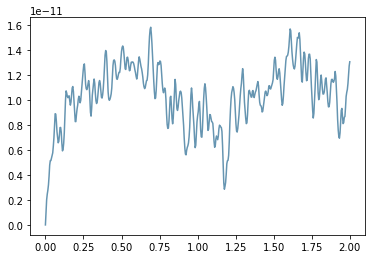

In [17]:
vex = 1228
pos = np.where(stc_RAL2.vertices[0]==vex)
val = stc_RAL2.lh_data[pos[0][0],:]
data_lh_RAL2 = stc_RAL2.lh_data
data_RAL2 = stc_RAL2.data
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))

[72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 439, 440, 44

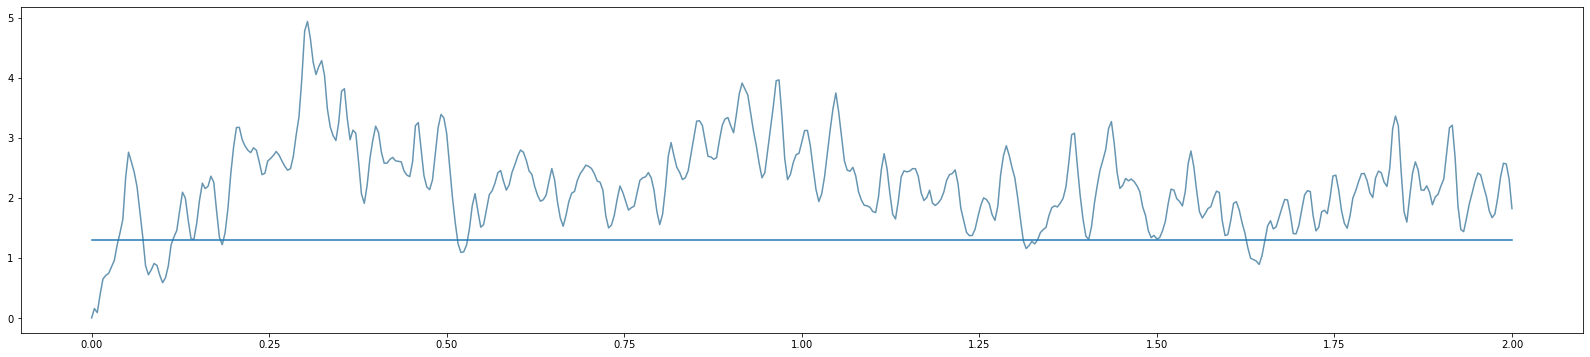

In [40]:
vex = 1273
stc = stc_EFE2
stc_p = stc_EFE2_p

pos = np.where(stc_p.vertices[0]==vex)
val = stc_p.lh_data[pos[0][0],:]
data_p_lh = stc_p.lh_data
data_p = stc_p.data
plt.figure(figsize=(28,6))
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
plt.plot(np.arange(501)*2/500,np.ones((501))*1.302)
sig = []
for i in range(501-60):
    if min(val[i:i+50])>1.302:
        sig.append(i+25)
print(sig)

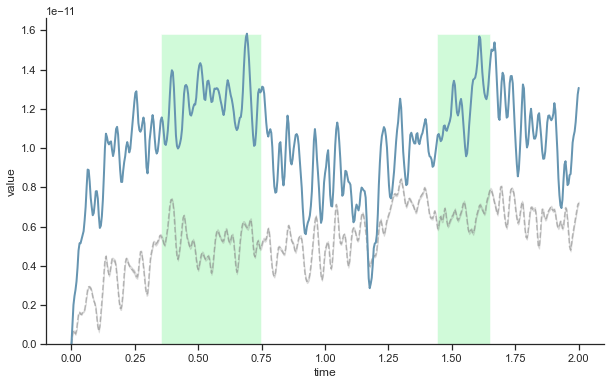

In [55]:
vex = 1228
stc = stc_RAL2

pos = np.where(stc.vertices[0]==vex)
val = stc.lh_data[pos[0][0],:]
data_lh = stc.lh_data
data = stc.data

value = []
time = []
value_tar = []
time_tar = []
for i in range(np.shape(data_lh)[1]):
    value_tar.append(val[i])
    time_tar.append(i/250)
for i in range(np.shape(data)[0]):
    for j in range(np.shape(data)[1]):
        value.append(data[i,j])
        time.append(j/250)
data = {'value':value,'time':time}
data = pd.DataFrame(data)
data_tar = {'value_tar':value_tar,'time_tar':time_tar}
data_tar = pd.DataFrame(data_tar)
plt.figure(figsize=(10,6))
sns.set(style='ticks')
sns.despine()
plt.bar(x=0.55,height=np.max(val),width=0.391,color=(229/255, 249/255, 224/255),alpha=0.6)
plt.bar(x=1.546,height=np.max(val),width=0.211,color=(229/255, 249/255, 224/255),alpha=0.6)
sns.lineplot(x='time',y='value',data=data,color='grey',dashes=True,ci=99,alpha=0.5,linestyle='--')
# plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
sns.lineplot(x='time_tar',y='value_tar',data=data_tar,color=(102/255,149/255,177/255),linewidth=2)
sns.set(style='ticks')
sns.despine()

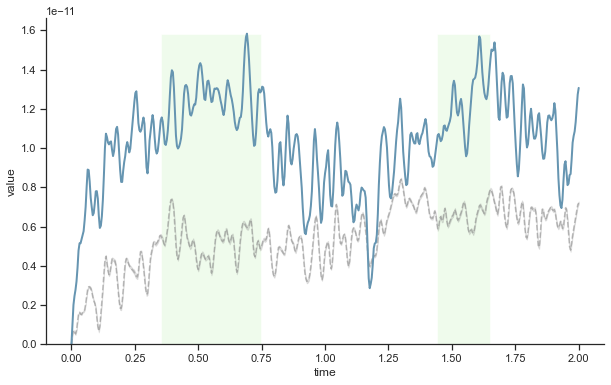

In [58]:
# RAL2
vex = 1228
stc = stc_RAL2

pos = np.where(stc.vertices[0]==vex)
val = stc.lh_data[pos[0][0],:]
data_lh = stc.lh_data
data = stc.data

value = []
time = []
value_tar = []
time_tar = []
for i in range(np.shape(data_lh)[1]):
    value_tar.append(val[i])
    time_tar.append(i/250)
for i in range(np.shape(data)[0]):
    for j in range(np.shape(data)[1]):
        value.append(data[i,j])
        time.append(j/250)
data = {'value':value,'time':time}
data = pd.DataFrame(data)
data_tar = {'value_tar':value_tar,'time_tar':time_tar}
data_tar = pd.DataFrame(data_tar)
plt.figure(figsize=(10,6))
sns.set(style='ticks')
sns.despine()
plt.bar(x=0.55,height=np.max(val),width=0.391,color=(229/255, 249/255, 224/255),alpha=0.6)
plt.bar(x=1.546,height=np.max(val),width=0.211,color=(229/255, 249/255, 224/255),alpha=0.6)
sns.lineplot(x='time',y='value',data=data,color='grey',dashes=True,ci=99,alpha=0.5,linestyle='--')
# plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
sns.lineplot(x='time_tar',y='value_tar',data=data_tar,color=(102/255,149/255,177/255),linewidth=2)
sns.set(style='ticks')
sns.despine()

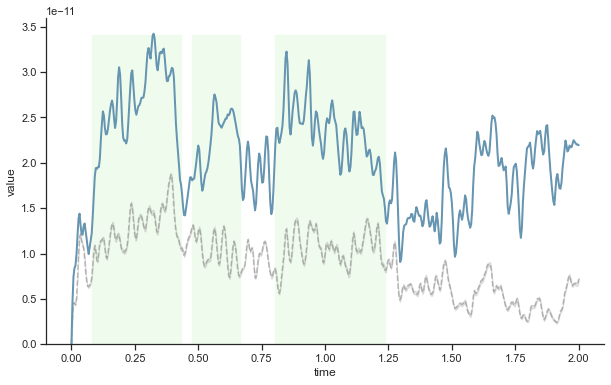

In [59]:
# RAI1
vex = 1801
stc_RAI1 = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_beta')
stc_RAI1_p = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_mlog10_p_val')
DATA_RAI1 = stc_RAI1.data
stc_RAI1.data = np.where(DATA_RAI1 <= 0, -DATA_RAI1, 0)
stc = stc_RAI1

pos = np.where(stc.vertices[0]==vex)
val = stc.rh_data[pos[0][0],:]
data_rh = stc.rh_data
data = stc.data

value = []
time = []
value_tar = []
time_tar = []
for i in range(np.shape(data_rh)[1]):
    value_tar.append(val[i])
    time_tar.append(i/250)
for i in range(np.shape(data)[0]):
    for j in range(np.shape(data)[1]):
        value.append(data[i,j])
        time.append(j/250)
data = {'value':value,'time':time}
data = pd.DataFrame(data)
data_tar = {'value_tar':value_tar,'time_tar':time_tar}
data_tar = pd.DataFrame(data_tar)
plt.figure(figsize=(10,6))
sns.set(style='ticks')
sns.despine()
plt.bar(x=0.256,height=np.max(val),width=0.36,color=(229/255, 249/255, 224/255),alpha=0.6)
plt.bar(x=1.02,height=np.max(val),width=0.44,color=(229/255, 249/255, 224/255),alpha=0.6)
plt.bar(x=0.57,height=np.max(val),width=0.2,color=(229/255, 249/255, 224/255),alpha=0.6)
sns.lineplot(x='time',y='value',data=data,color='grey',dashes=True,ci=99,alpha=0.5,linestyle='--')
# plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
sns.lineplot(x='time_tar',y='value_tar',data=data_tar,color=(102/255,149/255,177/255),linewidth=2)
sns.set(style='ticks')
sns.despine()

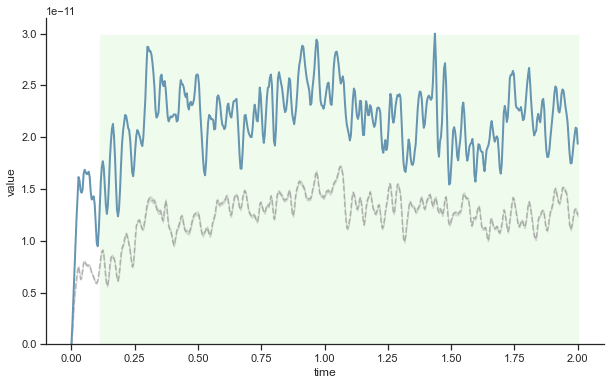

In [63]:
# AL2
vex = 1274
stc = stc_AL2

pos = np.where(stc.vertices[0]==vex)
val = stc.lh_data[pos[0][0],:]
data_lh = stc.lh_data
data = stc.data

value = []
time = []
value_tar = []
time_tar = []
for i in range(np.shape(data_lh)[1]):
    value_tar.append(val[i])
    time_tar.append(i/250)
for i in range(np.shape(data)[0]):
    for j in range(np.shape(data)[1]):
        value.append(data[i,j])
        time.append(j/250)
data = {'value':value,'time':time}
data = pd.DataFrame(data)
data_tar = {'value_tar':value_tar,'time_tar':time_tar}
data_tar = pd.DataFrame(data_tar)
plt.figure(figsize=(10,6))
sns.set(style='ticks')
sns.despine()
plt.bar(x=1.056,height=np.max(val),width=1.896,color=(229/255, 249/255, 224/255),alpha=0.6)

sns.lineplot(x='time',y='value',data=data,color='grey',dashes=True,ci=99,alpha=0.5,linestyle='--')
# plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
sns.lineplot(x='time_tar',y='value_tar',data=data_tar,color=(102/255,149/255,177/255),linewidth=2)
sns.set(style='ticks')
sns.despine()

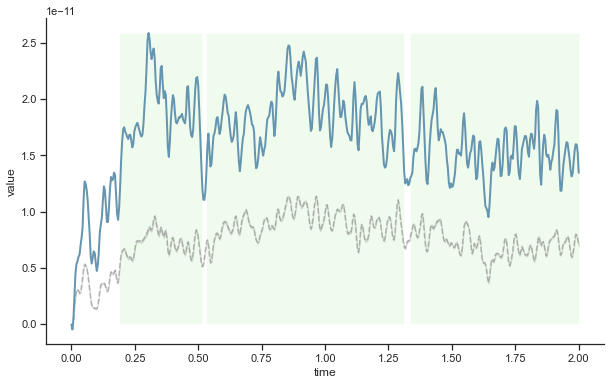

In [64]:
# EFE2
vex = 1273
stc = stc_EFE2

pos = np.where(stc.vertices[0]==vex)
val = stc.lh_data[pos[0][0],:]
data_lh = stc.lh_data
data = stc.data

value = []
time = []
value_tar = []
time_tar = []
for i in range(np.shape(data_lh)[1]):
    value_tar.append(val[i])
    time_tar.append(i/250)
for i in range(np.shape(data)[0]):
    for j in range(np.shape(data)[1]):
        value.append(data[i,j])
        time.append(j/250)
data = {'value':value,'time':time}
data = pd.DataFrame(data)
data_tar = {'value_tar':value_tar,'time_tar':time_tar}
data_tar = pd.DataFrame(data_tar)
plt.figure(figsize=(10,6))
sns.set(style='ticks')
sns.despine()
plt.bar(x=0.352,height=np.max(val),width=0.328,color=(229/255, 249/255, 224/255),alpha=0.6)
plt.bar(x=0.922,height=np.max(val),width=0.78,color=(229/255, 249/255, 224/255),alpha=0.6)
plt.bar(x=1.668,height=np.max(val),width=0.664,color=(229/255, 249/255, 224/255),alpha=0.6)

sns.lineplot(x='time',y='value',data=data,color='grey',dashes=True,ci=99,alpha=0.5,linestyle='--')
# plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
sns.lineplot(x='time_tar',y='value_tar',data=data_tar,color=(102/255,149/255,177/255),linewidth=2)
sns.set(style='ticks')
sns.despine()

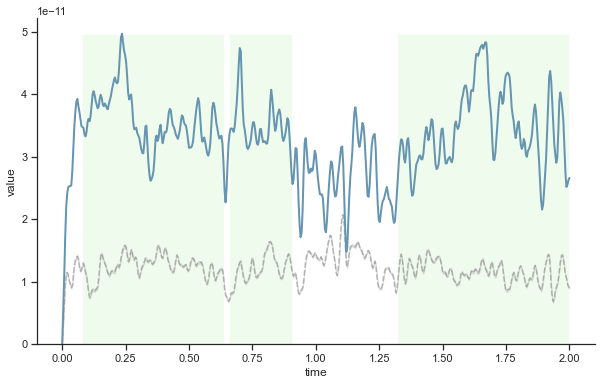

In [61]:
# AI1
vex = 973
stc_AI1 = mne.read_source_estimate('./stc_result/reg_SCE_AI1_beta')
stc_AI1_p = mne.read_source_estimate('./stc_result/reg_SCE_AI1_mlog10_p_val')
DATA_AI1 = stc_AI1.data
stc_AI1.data = np.where(DATA_AI1 <= 0, -DATA_AI1, 0)

stc = stc_AI1

pos = np.where(stc.vertices[0]==vex)
val = stc.lh_data[pos[0][0],:]
data_lh = stc.lh_data
data = stc.data

value = []
time = []
value_tar = []
time_tar = []
for i in range(np.shape(data_lh)[1]):
    value_tar.append(val[i])
    time_tar.append(i/250)
for i in range(np.shape(data)[0]):
    for j in range(np.shape(data)[1]):
        value.append(data[i,j])
        time.append(j/250)
data = {'value':value,'time':time}
data = pd.DataFrame(data)
data_tar = {'value_tar':value_tar,'time_tar':time_tar}
data_tar = pd.DataFrame(data_tar)
plt.figure(figsize=(10,6))
sns.set(style='ticks')
sns.despine()
plt.bar(x=0.358,height=np.max(val),width=0.556,color=(229/255, 249/255, 224/255),alpha=0.6)
plt.bar(x=0.782,height=np.max(val),width=0.251,color=(229/255, 249/255, 224/255),alpha=0.6)
plt.bar(x=1.66,height=np.max(val),width=0.68,color=(229/255, 249/255, 224/255),alpha=0.6)

sns.lineplot(x='time',y='value',data=data,color='grey',dashes=True,ci=99,alpha=0.5,linestyle='--')
# plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
sns.lineplot(x='time_tar',y='value_tar',data=data_tar,color=(102/255,149/255,177/255),linewidth=2)
sns.set(style='ticks')
sns.despine()

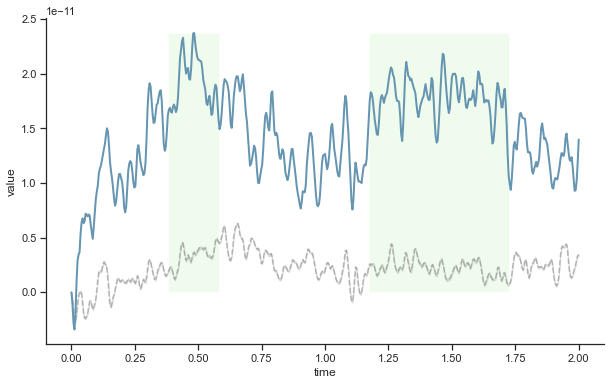

In [60]:
# EFE1
vex = 1995
stc = stc_EFE1

pos = np.where(stc.vertices[0]==vex)
val = stc.lh_data[pos[0][0],:]
data_lh = stc.lh_data
data = stc.data

value = []
time = []
value_tar = []
time_tar = []
for i in range(np.shape(data_lh)[1]):
    value_tar.append(val[i])
    time_tar.append(i/250)
for i in range(np.shape(data)[0]):
    for j in range(np.shape(data)[1]):
        value.append(data[i,j])
        time.append(j/250)
data = {'value':value,'time':time}
data = pd.DataFrame(data)
data_tar = {'value_tar':value_tar,'time_tar':time_tar}
data_tar = pd.DataFrame(data_tar)
plt.figure(figsize=(10,6))
sns.set(style='ticks')
sns.despine()
plt.bar(x=0.48,height=np.max(val),width=0.2,color=(229/255, 249/255, 224/255),alpha=0.6)
plt.bar(x=1.448,height=np.max(val),width=0.552,color=(229/255, 249/255, 224/255),alpha=0.6)

sns.lineplot(x='time',y='value',data=data,color='grey',dashes=True,ci=99,alpha=0.5,linestyle='--')
# plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
sns.lineplot(x='time_tar',y='value_tar',data=data_tar,color=(102/255,149/255,177/255),linewidth=2)
sns.set(style='ticks')
sns.despine()

In [ ]:
# RAI vex
vex = 1801
stc = stc_RAI1
stc_p = stc_RAI1_p

pos = np.where(stc_p.vertices[0]==vex)
val = stc_p.rh_data[pos[0][0],:]
data_p_lh = stc_p.rh_data
data_p = stc_p.data
plt.figure(figsize=(28,6))
plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
plt.plot(np.arange(501)*2/500,np.ones((501))*1.302)
sig = []
for i in range(501-60):
    if min(val[i:i+50])>1.302:
        sig.append(i+25)
print(sig)

In [ ]:
# RAI vex
vex = 1801
stc_RAI1 = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_beta')
stc_RAI1_p = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_mlog10_p_val')
DATA_RAI1 = stc_RAI1.data
stc_RAI1.data = np.where(DATA_RAI1 <= 0, -DATA_RAI1, 0)
stc = stc_RAI1

pos = np.where(stc.vertices[0]==vex)
val = stc.rh_data[pos[0][0],:]
data_rh = stc.rh_data
data = stc.data

value = []
time = []
value_tar = []
time_tar = []
for i in range(np.shape(data_rh)[1]):
    value_tar.append(val[i])
    time_tar.append(i/250)
for i in range(np.shape(data)[0]):
    for j in range(np.shape(data)[1]):
        value.append(data[i,j])
        time.append(j/250)
data = {'value':value,'time':time}
data = pd.DataFrame(data)
data_tar = {'value_tar':value_tar,'time_tar':time_tar}
data_tar = pd.DataFrame(data_tar)
plt.figure(figsize=(10,6))
sns.set(style='ticks')
sns.despine()
plt.bar(x=0.256,height=np.max(val),width=0.36,color='khaki',alpha=0.5)
plt.bar(x=1.02,height=np.max(val),width=0.44,color='khaki',alpha=0.5)
plt.bar(x=0.57,height=np.max(val),width=0.2,color='khaki',alpha=0.5)
sns.lineplot(x='time',y='value',data=data,color='grey',dashes=True,ci=99,alpha=0.5,linestyle='--')
# plt.plot(np.arange(501)*2/500,val,c=(102/255,149/255,177/255))
sns.lineplot(x='time_tar',y='value_tar',data=data_tar,color=(102/255,149/255,177/255),linewidth=2)
sns.set(style='ticks')
sns.despine()